# Частина 1. Власна нейронна мережа для Fashion-MNIST

## Імпорт бібліотек і завантаження даних

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


## Нормалізація та зміна розмірності

In [2]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape)

(60000, 28, 28, 1)


## Архітектура нейронної мережі

In [4]:
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 10, 10, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 10, 10, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 504,330 (1.92 MB)

 Trainable params: 504,010 (1.92 MB)

 Non-trainable params: 320 (1.25 KB)

## Компіляція

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Навчання моделі

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 182ms/step - accuracy: 0.7703 - loss: 0.6471 - val_accuracy: 0.6208 - val_loss: 2.3644
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 182ms/step - accuracy: 0.8484 - loss: 0.4212 - val_accuracy: 0.8745 - val_loss: 0.3434
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 182ms/step - accuracy: 0.8732 - loss: 0.3544 - val_accuracy: 0.8947 - val_loss: 0.2857
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 184ms/step - accuracy: 0.8838 - loss: 0.3224 - val_accuracy: 0.9027 - val_loss: 0.2745
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - accuracy: 0.8927 - loss: 0.2958 - val_accuracy: 0.9087 - val_loss: 0.2546
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - accuracy: 0.8999 - loss: 0.2773 - val_accuracy: 0.9162 - val_loss: 0.2272
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - accuracy: 0.9023 - loss: 0.2630 - val_accuracy: 0.9137 - val_loss: 0.2433
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 185ms/step - accuracy: 0.9079 - loss: 0

## Перевірка точності

In [8]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("CNN accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9254 - loss: 0.2312
CNN accuracy: 0.9254000186920166


## Графік навчання

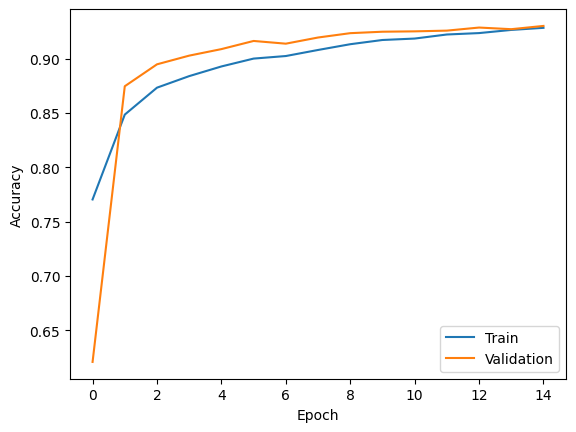

In [9]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

# Частина 2 — VGG16 Transfer Learning

## Підготовка Fashion-MNIST під VGG16

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

x_train_vgg = np.repeat(x_train, 3, axis=-1)
x_test_vgg = np.repeat(x_test, 3, axis=-1)

x_train_vgg = tf.image.resize(
    x_train_vgg,
    (64,64)
)

x_test_vgg = tf.image.resize(
    x_test_vgg,
    (64,64)
)

print(x_train_vgg.shape)

(60000, 64, 64, 3)


## Завантаження VGG16

In [11]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable = False

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Створення власного класифікатора

In [12]:
vgg_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 2, 2, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Компіляція

In [13]:
vgg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Навчання

In [14]:
history_vgg = vgg_model.fit(
    x_train_vgg,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 1033s 1s/step - accuracy: 0.7856 - loss: 0.6161 - val_accuracy: 0.8493 - val_loss: 0.4182
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 1045s 1s/step - accuracy: 0.8451 - loss: 0.4317 - val_accuracy: 0.8630 - val_loss: 0.3833
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 1027s 1s/step - accuracy: 0.8573 - loss: 0.3952 - val_accuracy: 0.8637 - val_loss: 0.3682


## Донавчання VGG16

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

vgg_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Навчання
history_fine = vgg_model.fit(
    x_train_vgg,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

#Перевірка
vgg_loss, vgg_acc = vgg_model.evaluate(
    x_test_vgg,
    y_test
)

print("VGG16 accuracy:", vgg_acc)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1504s 2s/step - accuracy: 0.8849 - loss: 0.3154 - val_accuracy: 0.8982 - val_loss: 0.2771
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1297s 2s/step - accuracy: 0.9092 - loss: 0.2500 - val_accuracy: 0.9035 - val_loss: 0.2612
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1282s 2s/step - accuracy: 0.9215 - loss: 0.2153 - val_accuracy: 0.9112 - val_loss: 0.2377
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1680s 2s/step - accuracy: 0.9305 - loss: 0.1886 - val_accuracy: 0.9148 - val_loss: 0.2306
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1743s 2s/step - accuracy: 0.9389 - loss: 0.1679 - val_accuracy: 0.9138 - val_loss: 0.2360
313/313 ━━━━━━━━━━━━━━━━━━━━ 206s 659ms/step - accuracy: 0.9105 - loss: 0.2528
VGG16 accuracy: 0.9104999899864197


## Висновки

In [ ]:
У ході виконання роботи було створено дві згорткові нейронні мережі для класифікації зображень Fashion-MNIST. 
Перша модель була побудована самостійно із використанням шарів Conv2D, MaxPooling, BatchNormalization та Dropout. 
Отримана точність була вищою або приблизно такою ж, як у багатошарової мережі, оскільки згорткова архітектура краще виділяє просторові 
ознаки зображень.
Друга модель використовувала VGG16 як попередньо навчену згорткову основу. За допомогою transfer learning було виконано виділення ознак та подальше 
донавчання останніх шарів мережі. 
Порівняння показало, що CNN моделі краще підходять для роботи із зображеннями, ніж звичайні багатошарові мережі. 